### 1 c) Simulation of the occurrence of Septic Shock
**Septic shock** is a critical condition characterized by profound systemic vasodilation in response to a severe infection. This causes an abrupt drop in blood pressure (severe hypotension) that compromises organ perfusion.

To simulate this state of distributive shock in our $WK_2$ model:
* We will drastically reduce **Peripheral Resistance ($R_P$)** (e.g., to 40% of its baseline value) to reflect extreme vasodilation.
* We will moderately increase **Compliance ($C_A$)** (e.g., 20% above the baseline value) due to the significant relaxation of vascular tone.

In [1]:
# -------------------------------------------------------------------------
# GENERAL USE MODULES AND FLOW FUNCTION (EXCITATION)
# -------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

def Q_Sim(Qmax, T, t):
    """
    Generation of a FLOW signal (Half-sine) similar to human [ml/s]
    """
    Escala_ml = 1e5 * (Qmax / 8.8) # Adjustment to (500 ml/s)
    Q = Escala_ml * ((7.9853e-06 + 2.6617e-05*np.sin(2*np.pi*t/T+0.29498) +
                      2.3616e-05*np.sin(4*np.pi*t/T-1.1403) - 1.9016e-05*np.sin(6*np.pi*t/T+0.40435) -
                      8.5899e-06*np.sin(8*np.pi*t/T-1.1892) - 2.436e-06*np.sin(10*np.pi*t/T-1.4918) +
                      1.4905e-06*np.sin(12*np.pi*t/T+1.0536) + 1.3581e-06*np.sin(14*np.pi*t/T-0.47666) -
                      6.3031e-07*np.sin(16*np.pi*t/T+0.93768) - 4.5335e-07*np.sin(18*np.pi*t/T-0.79472) -
                      4.5184e-07*np.sin(20*np.pi*t/T-1.4095) - 5.6583e-07*np.sin(22*np.pi*t/T-1.3629) +
                      4.9522e-07*np.sin(24*np.pi*t/T+0.52495) + 1.3049e-07*np.sin(26*np.pi*t/T-0.97261) -
                      4.1072e-08*np.sin(28*np.pi*t/T-0.15685) - 2.4182e-07*np.sin(30*np.pi*t/T-1.4052) -
                      6.6217e-08*np.sin(32*np.pi*t/T-1.3785) - 1.5511e-07*np.sin(34*np.pi*t/T-1.2927) +
                      2.2149e-07*np.sin(36*np.pi*t/T+0.68178) + 6.7621e-08*np.sin(38*np.pi*t/T-0.98825) +
                      1.0973e-07*np.sin(40*np.pi*t/T+1.4327) - 2.5559e-08*np.sin(42*np.pi*t/T-1.2372) -
                      3.5079e-08*np.sin(44*np.pi*t/T+0.2328)))
    return Q

In [2]:
# -------------------------------------------------------------------------
# NUMERICAL RESOLUTION OF THE WK2 MODEL (EULER'S METHOD)
# -------------------------------------------------------------------------

def resolver_wk2_euler(Q, t, Ca, Rp):
    """
    Solves the Differential Equation of the 2-element Windkessel
    dP/dt = Q/Ca - P/(Rp*Ca)
    """
    dt = t[1] - t[0]
    P = np.zeros(len(t))

    # Initial condition (we assume a low start due to the state of shock)
    P[0] = 50.0

    for i in range(1, len(t)):
        dP_dt = (Q[i-1] / Ca) - (P[i-1] / (Rp * Ca))
        P[i] = P[i-1] + (dP_dt * dt)

    return P

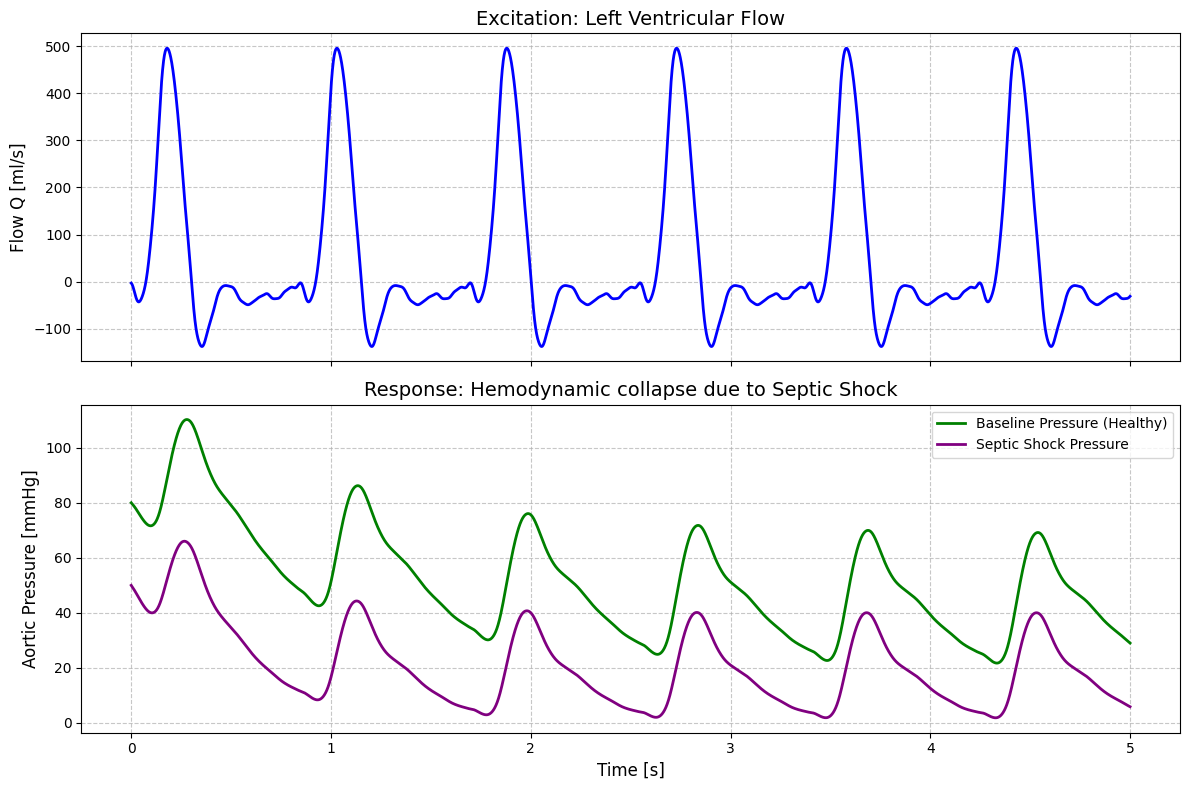

In [3]:
# -------------------------------------------------------------------------
# SIMULATION 1c: SEPTIC SHOCK
# -------------------------------------------------------------------------

# 1. Definition of the time and flow vector
Ts = 0.001
t = np.arange(0, 5, Ts)
T0 = 0.85
Qmax = 500

Q_entrada = Q_Sim(Qmax, T0, t)

# 2. Baseline Physiological Parameters
Ca_basal = 1.1  # ml/mmHg
Rp_basal = 0.9  # mmHg·s/ml

# 3. Parameters for Septic Shock (Brutal drop in Rp, increase in Ca)
Ca_sepsis = Ca_basal * 1.20
Rp_sepsis = Rp_basal * 0.40

# 4. Calculation of pressures
# We recalculate the baseline with a normal initial condition (80) so the graph is accurate
def resolver_wk2_euler_basal(Q, t, Ca, Rp):
    dt = t[1] - t[0]
    P = np.zeros(len(t))
    P[0] = 80.0
    for i in range(1, len(t)):
        P[i] = P[i-1] + (((Q[i-1] / Ca) - (P[i-1] / (Rp * Ca))) * dt)
    return P

P_basal = resolver_wk2_euler_basal(Q_entrada, t, Ca_basal, Rp_basal)
P_sepsis = resolver_wk2_euler(Q_entrada, t, Ca_sepsis, Rp_sepsis) # Uses P[0]=50

# 5. Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(t, Q_entrada, 'b', linewidth=2)
ax1.set_ylabel('Flow Q [ml/s]', fontsize=12)
ax1.set_title('Excitation: Left Ventricular Flow', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(t, P_basal, 'g', linewidth=2, label='Baseline Pressure (Healthy)')
ax2.plot(t, P_sepsis, 'purple', linewidth=2, label='Septic Shock Pressure')
ax2.set_xlabel('Time [s]', fontsize=12)
ax2.set_ylabel('Aortic Pressure [mmHg]', fontsize=12)
ax2.set_title('Response: Hemodynamic collapse due to Septic Shock', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Conclusion of the analysis (1 c)
The septic shock simulation reflects the patient's hemodynamic collapse:

1. **Severe Hypotension (Drop in DC component):** The purple curve is deeply sunken compared to the baseline. By reducing the peripheral resistance ($R_P$) to less than half, the system cannot maintain the mean pressure. Blood flows to the periphery with almost no opposition.
2. **Pronounced Diastolic Discharge:** In the diastolic phase (when the inflow is zero), it is observed that the pressure curve falls abruptly. The time constant $\tau = R_P \cdot C_A$ of the circuit has decreased significantly. The system discharges much faster into the peripheral circulation, compromising tissue perfusion.